# INR

In [10]:
import graphviz

# Create Graphviz Digraph
dot = graphviz.Digraph('LesionINR_Detailed', comment='Detailed LesionINR Architecture', format='png')
dot.attr(
    rankdir='TB', 
    nodesep='0.4', 
    ranksep='0.6', 
    splines='ortho',
    fontname='Helvetica'
)

# Global Node Attributes
dot.attr('node', fontname='Helvetica', shape='rect', style='filled,rounded', fontsize='10')
dot.attr('edge', fontname='Helvetica', fontsize='9', color='#444444')

# Color Scheme
c_input = '#E1F5FE'       # Light Blue
c_encoder = '#E8F5E9'     # Light Green
c_latent = '#FFF3E0'      # Light Orange
c_siren = '#FFEBEE'       # Light Red
c_film = '#F3E5F5'        # Light Purple
c_out = '#ECEFF1'         # Slate Grey

# ==========================================
# 1. INPUT TENSORS
# ==========================================
with dot.subgraph(name='cluster_inputs') as c:
    c.attr(label='Input Tensors [Batch Size N]', style='dashed', color='#888888', fontcolor='#555555')
    c.node('x_spatial', 'Spatial Coordinates (x)\nShape: [B, 3]', fillcolor=c_input)
    c.node('x_time', 'Raw Time Scalar (t)\nShape: [B, 1]', fillcolor=c_input)
    c.node('p_idx', 'Patient Index\nShape: [B, 1]', fillcolor=c_input)

# ==========================================
# 2. TIME ENCODING & PATIENT EMBEDDINGS
# ==========================================
with dot.subgraph(name='cluster_encoding') as c:
    c.attr(label='Feature Preparation & Concatenation', style='dashed', color='#888888', fontcolor='#555555')
    
    # Time Encoding Pathway
    c.node('t_norm', 'Time Normalization\nt_norm = t / max_t', fillcolor=c_encoder)
    c.node('t_harm', 'Harmonic Expansion\n[2^0, 2^1, ..., 2^(freqs-1)] * pi', fillcolor=c_encoder)
    c.node('t_sincos', 'Sine/Cosine Concat\n[sin(angles), cos(angles)]\nShape: [B, 2 * time_freqs]', fillcolor=c_encoder)
    
    # Patient Vector Pathway
    c.node('p_embed', 'nn.Embedding Table\n[Bum_patients, latent_dim]\nShape: [B, latent_dim]', fillcolor=c_latent)
    
    # Fusion
    c.node('cat_z', 'torch.cat([z_patient, t_encoded])\nShape: [B, latent_dim + (2 * time_freqs)]', shape='ellipse', fillcolor='#FFFFFF')

# ==========================================
# 3. LATENT ADAPTATION NETWORK (MLP)
# ==========================================
with dot.subgraph(name='cluster_latent_adapt') as c:
    c.attr(label='Latent Adapt Pipeline (self.latent_adapt)', style='dashed', color='#888888', fontcolor='#555555')
    c.node('adapt_l1', 'Linear(latent_dim + 2*freqs, latent_dim)\n+ LeakyReLU', fillcolor=c_latent)
    c.node('adapt_l2', 'Linear(latent_dim, latent_dim)\n+ LeakyReLU', fillcolor=c_latent)
    c.node('adapt_norm', 'LayerNorm(latent_dim)\nModulation Vector z: [B, latent_dim]', fillcolor=c_latent)

# ==========================================
# 4. SIREN TRUNK & FiLM MODULATION
# ==========================================
with dot.subgraph(name='cluster_siren_trunk') as c:
    c.attr(label='SIREN Trunk Architecture (self.first_layer & self.layers)', style='dashed', color='#888888', fontcolor='#555555')
    
    # First Siren Layer
    c.node('film_0', 'First Layer FiLM Projection\nconditioning_lin(z) -> [B, 1, 2*hidden_dim]\nChunk -> (gamma_0, beta_0)', fillcolor=c_film)
    c.node('siren_0', 'First SirenLayer (omega_0 = 45.0)\nsin( 45.0 * (gamma_0 * Linear(3, hidden_dim) + beta_0) )\nShape: [B, hidden_dim]', fillcolor=c_siren)
    
    # Middle Siren Layers
    c.node('film_k', 'Layer k FiLM Projection\nconditioning_lin(z) -> [B, 1, 2*hidden_dim]\nChunk -> (gamma_k, beta_k)', fillcolor=c_film)
    c.node('siren_k', 'SirenLayer k x N (omega_0 = 30.0)\nsin( 30.0 * (gamma_k * Linear(hidden_dim, hidden_dim) + beta_k) )\nShape: [B, hidden_dim]', fillcolor=c_siren)

# ==========================================
# 5. FINAL PREDICTION HEAD
# ==========================================
dot.node('final_linear', 'final_layer (nn.Linear)\n[hidden_dim -> output_dim]', fillcolor=c_out)
dot.node('output', 'Lesion Prediction Output\nShape: [B, output_dim]', shape='doubleoctagon', fillcolor='#FFFFFF')

# ==========================================
# GRAPH EDGES & DATAFLOW
# ==========================================

# Inputs -> Encoders
dot.edge('x_time', 't_norm', label='raw_time')
dot.edge('t_norm', 't_harm')
dot.edge('t_harm', 't_sincos')

dot.edge('p_idx', 'p_embed', label='patient_idx')

# Encoders -> Fusion
dot.edge('t_sincos', 'cat_z', label='t_encoded')
dot.edge('p_embed', 'cat_z', label='z_patient')

# Fusion -> Adapt MLP
dot.edge('cat_z', 'adapt_l1')
dot.edge('adapt_l1', 'adapt_l2')
dot.edge('adapt_l2', 'adapt_norm')

# Latent Conditioning Vector z to FiLM Generators
dot.edge('adapt_norm', 'film_0', label='z')
dot.edge('adapt_norm', 'film_k', label='z')

# Spatial Coords & FiLM -> First Layer
dot.edge('x_spatial', 'siren_0', label='spatial_coords [B, 3]')
dot.edge('film_0', 'siren_0', label='(gamma_0, beta_0)')

# Trunk Flow
dot.edge('siren_0', 'siren_k', label='x_out [B, hidden_dim]')
dot.edge('film_k', 'siren_k', label='(gamma_k, beta_k)')

# Final Output
dot.edge('siren_k', 'final_linear', label='x_out [B, hidden_dim]')
dot.edge('final_linear', 'output')

# Save and render
dot.render('lesion_inr_detailed', view=True)

'lesion_inr_detailed.png'

In [20]:
# Install: pip install graphviz
import graphviz

dot = graphviz.Digraph('LesionINR', comment='LesionINR Model Flow', format='png')
dot.attr(rankdir='TB', size='10,10', fontname='Helvetica')

dot.attr('node', fontname='Helvetica', shape='rect', style='filled', fontsize='10')
dot.attr('edge', fontname='Helvetica', fontsize='9', color='#333333')


# Input Nodes
dot.node('coords', 'Spatial Coordinates (xyz)\n[B, N, 3]', shape='box', style='filled', fillcolor='#E1F5FE')
dot.node('time', 'Time [days]\n[B, 1]', shape='box', style='filled', fillcolor='#E1F5FE')
dot.node('patient', 'Lesion ID\n[B, 1]', shape='box', style='filled', fillcolor='#E1F5FE')

# Processing Nodes
dot.node('time_enc', 'TimeEncoder\nFourier/Harmonic\n[B, 2*time_freqs]', shape='box', style='filled', fillcolor='#E8F5E9')
dot.node('embed', 'Embedding\n[B, latent_dim]', shape='box', style='filled', fillcolor='#FFF3E0')
dot.node('adapt', 'MLP for latent_adapation\n[B, latent_dim]', shape='box', style='filled', fillcolor='#FFF3E0')

# SIREN Layers
dot.node('siren_first', 'Higher frequency SirenLayer\n(ω_0=45)\n[B, N, hidden_dim]', shape='box', style='filled', fillcolor='#FFEBEE')
dot.node('siren_mid', 'SirenLayers x N times\nLayer-wise FiLM (ω_0=30)\n[B, N, hidden_dim]', shape='box', style='filled', fillcolor='#FFEBEE')
dot.node('out', 'Final Linear Layer\n[B, N, output_dim]', shape='box', style='filled', fillcolor='#F3E5F5')

# Edges
dot.edge('time', 'time_enc')
dot.edge('patient', 'embed')
dot.edge('time_enc', 'adapt')
dot.edge('embed', 'adapt')

dot.edge('coords', 'siren_first')
dot.edge('adapt', 'siren_first', label='latent vector modulation')
dot.edge('adapt', 'siren_mid', label='latent vector modulation')

dot.edge('siren_first', 'siren_mid')
dot.edge('siren_mid', 'out')

# Save diagram
dot.render('lesion_inr_diagram', view=True)

'lesion_inr_diagram.png'

# LSTM


In [16]:
import graphviz

dot = graphviz.Digraph('LesionLatentLSTM_Normal', comment='High-Level LesionLatentLSTM Flow', format='png')
dot.attr(rankdir='TB', fontname='Helvetica')

# Global styling
dot.attr('node', fontname='Helvetica', shape='rect', style='filled', fontsize='10')
dot.attr('edge', fontname='Helvetica', fontsize='9', color='#333333')

# Palette
c_grid = '#E1F5FE'     # Light Blue (Spatial/Grids)
c_ae = '#FFF3E0'       # Light Orange (Autoencoder)
c_time = '#E8F5E9'     # Light Green (Time)
c_rnn = '#FFEBEE'      # Light Red (LSTM Core)
c_out = '#F3E5F5'      # Light Purple (Output)

# Inputs
dot.node('grids_in', 'Input Grids\n[B, T, 1, D, H, W]', fillcolor=c_grid)
dot.node('times_in', 'Target Time\n[B, T + Δt]', fillcolor=c_grid)
dot.node('p_idx', 'Lesion ID\n[B, 1]', fillcolor=c_grid)
dot.node('embed', 'Embedding\n[B, latent_dim]', shape='box', style='filled', fillcolor='#FFF3E0')

# Autoencoder Components
dot.node('encoder', '3D Conv Encoder\n[B, T, latent_dim]', fillcolor=c_ae)

# Temporal Conditioning & LSTM
dot.node('t_enc', 'TimeEncoder\nFourier/Harmonic\n[B, 2 * time_freqs]', fillcolor=c_time)
dot.node('lstm', 'LSTM\nPredicted Latent Vectors\n[B, Steps, hidden_dim]', fillcolor=c_rnn)
dot.node('z_pred', 'MLP\n[B, Steps, latent_dim]',  fillcolor=c_rnn)

# Output Decoder
dot.node('decoder', '3D Conv Decoder\n[B, Steps, 1, D, H, W]', fillcolor=c_ae)

# Flow Edges
dot.edge('grids_in', 'encoder')
dot.edge('encoder', 'lstm', label='Latent Vector     ')

dot.edge('times_in', 't_enc')
dot.edge('t_enc', 'lstm')
dot.edge('p_idx', 'embed')
dot.edge('embed', 'lstm')

dot.edge('lstm', 'z_pred', label=' hidden_dim -> latent_dim')
dot.edge('z_pred', 'decoder')

# Save and render
dot.render('lesion_latent_lstm_normal', view=True)

'lesion_latent_lstm_normal.png'

In [7]:
import graphviz

dot = graphviz.Digraph('LesionLatentLSTM_Detailed', comment='Detailed LesionLatentLSTM Architecture', format='png')
dot.attr(rankdir='TB', nodesep='0.4', ranksep='0.5', splines='ortho', fontname='Helvetica')

# Global styling
dot.attr('node', fontname='Helvetica', shape='rect', style='filled,rounded', fontsize='9')
dot.attr('edge', fontname='Helvetica', fontsize='8', color='#444444')

# Color Palette
c_input = '#E1F5FE'     # Light Blue
c_encoder = '#E0F2F1'   # Teal/Green (Encoder)
c_time = '#E8F5E9'      # Light Green
c_patient = '#FFF3E0'   # Light Orange
c_lstm = '#FFEBEE'     # Light Red (LSTM Core)
c_decoder = '#F3E5F5'   # Light Purple (Decoder)
c_out = '#ECEFF1'       # Slate Grey

# ==========================================
# 1. INPUT SECTION
# ==========================================
with dot.subgraph(name='cluster_inputs') as c:
    c.attr(label='Model Inputs', style='dashed', color='#888888', fontcolor='#555555')
    c.node('grids_in', 'Observed Occupancy Grids\n[B, T, 1, 64, 64, 64]', fillcolor=c_input)
    c.node('times_in', 'Target Visit Timestamps\n[B, Steps + 1]', fillcolor=c_input)
    c.node('p_idx', 'Patient Index (Optional)\n[B, 1]', fillcolor=c_input)

# ==========================================
# 2. ENCODER 3D SUBGRAPH
# ==========================================
with dot.subgraph(name='cluster_encoder') as c:
    c.attr(label='3D Conv Encoder (Encoder3D)', style='dashed', color='#00695C', fontcolor='#00695C')
    c.node('enc_conv1', 'Conv3d(1, 32, k=3, p=1) + LeakyReLU', fillcolor=c_encoder)
    c.node('enc_down1', 'Conv3d(32, 32, k=4, s=2, p=1) [1/2] + LeakyReLU', fillcolor=c_encoder)
    c.node('enc_down2', 'Conv3d(32, 64, k=4, s=2, p=1) [1/4] + LeakyReLU', fillcolor=c_encoder)
    c.node('enc_down3', 'Conv3d(64, 128, k=4, s=2, p=1) [1/8] + LeakyReLU', fillcolor=c_encoder)
    c.node('enc_down4', 'Conv3d(128, 128, k=4, s=2, p=1) [1/16] + LeakyReLU', fillcolor=c_encoder)
    c.node('enc_pool', 'AdaptiveAvgPool3d((4,4,4))\nShape: [B, 128, 4, 4, 4]', fillcolor=c_encoder)
    c.node('enc_fc', 'Linear(128*4*4*4 -> latent_dim)\nShape: [B, latent_dim]', fillcolor=c_encoder)

# ==========================================
# 3. CONDITIONING & TIME ENCODING
# ==========================================
with dot.subgraph(name='cluster_conditioning') as c:
    c.attr(label='Temporal & Patient Conditioning', style='dashed', color='#2E7D32', fontcolor='#2E7D32')
    c.node('t_norm', 'Time Normalization\nt / max_t', fillcolor=c_time)
    c.node('t_harm', 'Harmonic Frequencies\n2^[0..freqs-1] * pi', fillcolor=c_time)
    c.node('t_concat', 'Sin/Cos Encoding\nShape: [B, 2 * time_freqs]', fillcolor=c_time)
    c.node('p_embed', 'nn.Embedding\nShape: [B, latent_dim]', fillcolor=c_patient)
    c.node('cat_rnn_in', 'torch.cat([z_curr, t_enc, (p_emb)])\nShape: [B, total_steps, input_dim]', shape='ellipse', fillcolor='#FFFFFF')

# ==========================================
# 4. RECURRENT LATENT CORE
# ==========================================
with dot.subgraph(name='cluster_lstm') as c:
    c.attr(label='Recurrent Latent Core', style='dashed', color='#C62828', fontcolor='#C62828')
    c.node('rnn_layer', 'nn.LSTM(input_dim, hidden_dim, num_layers=2)\nBatch First = True\nOutput Shape: [B, total_steps, hidden_dim]', fillcolor=c_lstm)
    c.node('fc_out', 'Linear(hidden_dim -> latent_dim)\nShape: [B, total_steps, latent_dim]', fillcolor=c_lstm)

# ==========================================
# 5. DECODER 3D SUBGRAPH
# ==========================================
with dot.subgraph(name='cluster_decoder') as c:
    c.attr(label='3D Conv Decoder (Decoder3D)', style='dashed', color='#6A1B9A', fontcolor='#6A1B9A')
    c.node('dec_fc', 'Linear(latent_dim -> 128*4*4*4)', fillcolor=c_decoder)
    c.node('dec_unflatten', 'Unflatten -> [B, 128, 4, 4, 4]', fillcolor=c_decoder)
    
    # UpResBlock Units
    c.node('dec_up1', 'UpResBlock3D 1 (x2)\nInterpolate + Conv3d(128, 128) + ResBlock3D\nShape: [B, 128, 8, 8, 8]', fillcolor=c_decoder)
    c.node('dec_up2', 'UpResBlock3D 2 (x4)\nInterpolate + Conv3d(128, 64) + ResBlock3D\nShape: [B, 64, 16, 16, 16]', fillcolor=c_decoder)
    c.node('dec_up3', 'UpResBlock3D 3 (x8)\nInterpolate + Conv3d(64, 32) + ResBlock3D\nShape: [B, 32, 32, 32, 32]', fillcolor=c_decoder)
    c.node('dec_up4', 'UpResBlock3D 4 (x16)\nInterpolate + Conv3d(32, 32) + ResBlock3D\nShape: [B, 32, 64, 64, 64]', fillcolor=c_decoder)
    
    # Refinement & Output Projection
    c.node('dec_refine', 'full_resolution_refine\nResidual Refinement (Conv3d + LeakyReLU)\nShape: [B, 32, 64, 64, 64]', fillcolor=c_decoder)
    c.node('dec_final', 'final_conv: Conv3d(32, 1, k=3, p=1)\nTarget Spatial Res Interpolation (if needed)', fillcolor=c_decoder)

# Final Output
dot.node('output', 'Predicted Occupancy Grid Logits\npreds: [B, total_steps, 1, 64, 64, 64]', shape='doubleoctagon', fillcolor=c_out)

# ==========================================
# EDGES & DATAFLOW
# ==========================================

# Encoder Flow
dot.edge('grids_in', 'enc_conv1')
dot.edge('enc_conv1', 'enc_down1')
dot.edge('enc_down1', 'enc_down2')
dot.edge('enc_down2', 'enc_down3')
dot.edge('enc_down3', 'enc_down4')
dot.edge('enc_down4', 'enc_pool')
dot.edge('enc_pool', 'enc_fc', label='Flatten')

# Time Encoding Flow
dot.edge('times_in', 't_norm')
dot.edge('t_norm', 't_harm')
dot.edge('t_harm', 't_concat')

# Patient Flow
dot.edge('p_idx', 'p_embed')

# Concatenation
dot.edge('enc_fc', 'cat_rnn_in', label='z_curr')
dot.edge('t_concat', 'cat_rnn_in', label='t_enc')
dot.edge('p_embed', 'cat_rnn_in', label='p_emb')

# Recurrent Core Flow
dot.edge('cat_rnn_in', 'rnn_layer')
dot.edge('rnn_layer', 'fc_out')

# Decoder Flow
dot.edge('fc_out', 'dec_fc', label='z_pred [per step]')
dot.edge('dec_fc', 'dec_unflatten')
dot.edge('dec_unflatten', 'dec_up1')
dot.edge('dec_up1', 'dec_up2')
dot.edge('dec_up2', 'dec_up3')
dot.edge('dec_up3', 'dec_up4')
dot.edge('dec_up4', 'dec_refine')
dot.edge('dec_refine', 'dec_final')
dot.edge('dec_final', 'output')

# Save and render
dot.render('lesion_latent_lstm_detailed', view=True)

'lesion_latent_lstm_detailed.png'

## NODE


In [32]:
import graphviz

dot = graphviz.Digraph('NeuralODE_INR_Normal', comment='High-Level NeuralODE_INR Architecture', format='png')
dot.attr(rankdir='TB', fontname='Helvetica')

# Global styling
dot.attr('node', fontname='Helvetica', shape='rect', style='filled', fontsize='10')
dot.attr('edge', fontname='Helvetica', fontsize='9', color='#333333')

# Color Palette
c_input = '#E1F5FE'     # Light Blue (Inputs)
c_patient = '#FFF3E0'   # Light Orange (Patient Latent)
c_ode = '#FFEBEE'       # Light Red (ODE Trajectory)
c_spatial = '#E8F5E9'   # Light Green (Fourier Spatial)
c_decoder = '#F3E5F5'   # Light Purple (Spatial Decoder)
c_out = '#ECEFF1'       # Slate Grey (Output)

# Input Nodes
dot.node('coords_in', 'Input Coordinates (x,y,z,t)\n [B, N, 4]', fillcolor=c_input)
dot.node('p_idx', 'Lesion ID\n [B]', fillcolor=c_input)

# Patient Embedding & Initial State
dot.node('p_embed', 'Embedding\n[B, patient_embed_dim]', fillcolor=c_patient)
dot.node('z0_net', 'MLP for initial_state z_0 \n[B, latent_dim]', fillcolor=c_patient)

# Neural ODE Integration Pathway
dot.node('time_norm', 'Shared Time Normalization\nt = mean(coords[..., 3]) / max_t\nShape: [B, 1]', fillcolor=c_ode)
dot.node('ode_solver', 'FixedStepODESolver RK4\nIntegrator over n_steps\nz_t = ODESolve(z0, f_theta, 0 -> t)\n[B, latent_dim]', fillcolor=c_ode)

# Spatial & Decoding Pathway
dot.node('fourier', 'FourierFeatures\n3D Spatial Encoding\n[B, N, spatial_in_dim]', fillcolor=c_spatial)
dot.node('decoder', 'SpatialDecoder (FiLM MLPs)\nModulated by z_t expanded to [B, N, latent_dim]', fillcolor=c_decoder)
dot.node('output', 'Logits\n[B, N, 1]', fillcolor=c_out)

# Flow Edges
dot.edge('p_idx', 'p_embed')
dot.edge('p_embed', 'z0_net')

dot.edge('coords_in', 'time_norm', label='Time Channel [..., 3]')
dot.edge('z0_net', 'ode_solver', label='z_0')
dot.edge('time_norm', 'ode_solver', label='t')
dot.edge('p_embed', 'ode_solver', label='Conditioning')

dot.edge('coords_in', 'fourier', label='Spatial Coords [..., :3]')
dot.edge('fourier', 'decoder', label='xyz_encoded')
dot.edge('ode_solver', 'decoder', label='z_t (expanded)')

dot.edge('decoder', 'output')

# Save and render
dot.render('neural_ode_inr_normal', view=True)

'neural_ode_inr_normal.png'

In [9]:
import graphviz

dot = graphviz.Digraph('NeuralODE_INR_Detailed', comment='Detailed NeuralODE_INR Architecture', format='png')
dot.attr(rankdir='TB', nodesep='0.4', ranksep='0.5', splines='ortho', fontname='Helvetica')

# Global styling
dot.attr('node', fontname='Helvetica', shape='rect', style='filled,rounded', fontsize='9')
dot.attr('edge', fontname='Helvetica', fontsize='8', color='#444444')

# Palette
c_input = '#E1F5FE'     # Light Blue
c_patient = '#FFF3E0'   # Light Orange
c_ode = '#FFEBEE'       # Light Red
c_spatial = '#E8F5E9'   # Light Green
c_film = '#F3E5F5'      # Light Purple
c_out = '#ECEFF1'       # Slate Grey

# ==========================================
# 1. INPUTS & EMBEDDINGS
# ==========================================
with dot.subgraph(name='cluster_inputs') as c:
    c.attr(label='Input Tensors [Batch Size B, N Points]', style='dashed', color='#888888', fontcolor='#555555')
    c.node('coords_in', 'Coords Input\n[B, N, 4]', fillcolor=c_input)
    c.node('p_idx', 'Patient Index\n[B]', fillcolor=c_input)

with dot.subgraph(name='cluster_patient_prep') as c:
    c.attr(label='Patient Trajectory Initialization', style='dashed', color='#E65100', fontcolor='#E65100')
    c.node('p_embed', 'nn.Embedding(num_patients, patient_embed_dim)\npatient_emb: [B, patient_embed_dim]', fillcolor=c_patient)
    c.node('z0_net', 'initial_state_net\nLinear(embed_dim, latent_dim) -> Tanh -> Linear\nz0: [B, latent_dim]', fillcolor=c_patient)

# ==========================================
# 2. ODE SOLVER & LATENT DYNAMICS
# ==========================================
with dot.subgraph(name='cluster_ode') as c:
    c.attr(label='Latent Neural ODE Trajectory (FixedStepODESolver)', style='dashed', color='#C62828', fontcolor='#C62828')
    c.node('shared_time', '_shared_time: coords[..., 3].mean(dim=1, keepdim=True)\nt = time / max_t -> [B, 1]', fillcolor=c_ode)
    c.node('dt_calc', 'Step Size Calculation\ndt = t / n_steps', fillcolor=c_ode)
    
    c.node('ode_func', 'LatentODEFunc f_theta(z, cond)\nLinear(latent+cond, 128) -> Tanh\n-> Linear(128, 128) -> Tanh -> Linear(128, latent)\ndz/dt: [B, latent_dim]', fillcolor=c_ode)
    
    c.node('rk4_loop', 'RK4 Numerical Integration Loop (n_steps)\nk1 = f(z, cond)\nk2 = f(z + 0.5*dt*k1, cond)\nk3 = f(z + 0.5*dt*k2, cond)\nk4 = f(z + dt*k3, cond)\nz_{next} = z + (dt/6)*(k1 + 2k2 + 2k3 + k4)', fillcolor=c_ode)
    c.node('z_t', 'Evaluated Latent State at Target Time\nz_t: [B, latent_dim]', shape='ellipse', fillcolor='#FFFFFF')

# ==========================================
# 3. SPATIAL FOURIER ENCODING
# ==========================================
with dot.subgraph(name='cluster_fourier') as c:
    c.attr(label='Mixed-Direction Spatial Fourier Encoding', style='dashed', color='#2E7D32', fontcolor='#2E7D32')
    c.node('xyz_slice', 'Spatial Coordinates\ncoords[..., :3]: [B, N, 3]', fillcolor=c_spatial)
    c.node('directions', 'Random Spherical Direction Projections\nx @ directions.T', fillcolor=c_spatial)
    c.node('freq_mult', 'Harmonic Scaling & Pi Scaling\nprojections * 2^[0..num_freqs-1] * pi', fillcolor=c_spatial)
    c.node('sincos_cat', 'Concat [x, sin(proj), cos(proj)]\nxyz_encoded: [B, N, spatial_in_dim]', fillcolor=c_spatial)

# ==========================================
# 4. SPATIAL DECODER & FiLM MODULATION
# ==========================================
with dot.subgraph(name='cluster_decoder') as c:
    c.attr(label='Spatial Decoder (SpatialDecoder with FiLM)', style='dashed', color='#6A1B9A', fontcolor='#6A1B9A')
    
    c.node('expand_zt', 'Expand Latent State over N points\nz_t_expanded: [B, N, latent_dim]', fillcolor=c_film)
    c.node('concat_in', 'torch.cat([xyz_encoded, z_t_expanded], dim=-1)\nShape: [B, N, spatial_in_dim + latent_dim]', shape='ellipse', fillcolor='#FFFFFF')
    
    c.node('film_proj', 'FiLM Linear Layers (self.film[i])\nLinear(latent_dim, 2*hidden_dim)\nChunk -> scale (gamma), shift (beta)', fillcolor=c_film)
    
    c.node('dec_layer1', 'Linear(spatial_in + latent, hidden_dim)\n-> ReLU\n-> FiLM: hidden * (1 + gamma) + beta', fillcolor=c_decoder)
    c.node('dec_layer_mid', 'Hidden Layers (x2)\nLinear(hidden_dim, hidden_dim) -> ReLU -> FiLM', fillcolor=c_decoder)
    c.node('dec_final', 'Final Linear Projection\nLinear(hidden_dim, 1)\n(bias initialized to -0.5)', fillcolor=c_decoder)

# Final Output
dot.node('output', 'Occupancy Prediction Logits\nlogits: [B, N, 1]', shape='doubleoctagon', fillcolor=c_out)

# ==========================================
# EDGES & DATAFLOW
# ==========================================

# Patient Pipeline
dot.edge('p_idx', 'p_embed')
dot.edge('p_embed', 'z0_net')

# Time & ODE Pipeline
dot.edge('coords_in', 'shared_time', label='coords[..., 3]')
dot.edge('shared_time', 'dt_calc')
dot.edge('z0_net', 'rk4_loop', label='z0')
dot.edge('dt_calc', 'rk4_loop', label='dt')
dot.edge('p_embed', 'ode_func', label='cond')
dot.edge('ode_func', 'rk4_loop', label='Evaluates dz/dt')
dot.edge('rk4_loop', 'z_t')

# Fourier Pipeline
dot.edge('coords_in', 'xyz_slice', label='coords[..., :3]')
dot.edge('xyz_slice', 'directions')
dot.edge('directions', 'freq_mult')
dot.edge('freq_mult', 'sincos_cat')

# Decoder & FiLM Pipeline
dot.edge('z_t', 'expand_zt')
dot.edge('sincos_cat', 'concat_in', label='xyz_encoded')
dot.edge('expand_zt', 'concat_in')

dot.edge('z_t', 'film_proj', label='z_t [B, latent_dim]')
dot.edge('concat_in', 'dec_layer1')
dot.edge('film_proj', 'dec_layer1', label='(gamma_0, beta_0)')

dot.edge('dec_layer1', 'dec_layer_mid')
dot.edge('film_proj', 'dec_layer_mid', label='(gamma_i, beta_i)')

dot.edge('dec_layer_mid', 'dec_final')
dot.edge('dec_final', 'output')

# Save and render
dot.render('neural_ode_inr_detailed', view=True)

'neural_ode_inr_detailed.png'

# Brain

In [1]:
import os
import importlib
os.chdir('/home/benjaminb/Dokumente/JKU/Semester_9/Practical_Work')

from utils import lesion_trajectory
importlib.reload(lesion_trajectory)
from utils.mri_dataloader import MRI_Dataloader

mdl = MRI_Dataloader()

In [2]:
mdl.cache_lesion_trajectories_from_n_scans(n_scans=20)
trjs = mdl.cache_lesion_trajectories

Found 30 trajectories with at least 20 scans.


/home/benjaminb/Dokumente/JKU/Semester_9/Practical_Work/utils/lesion_trajectory.py:388: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(


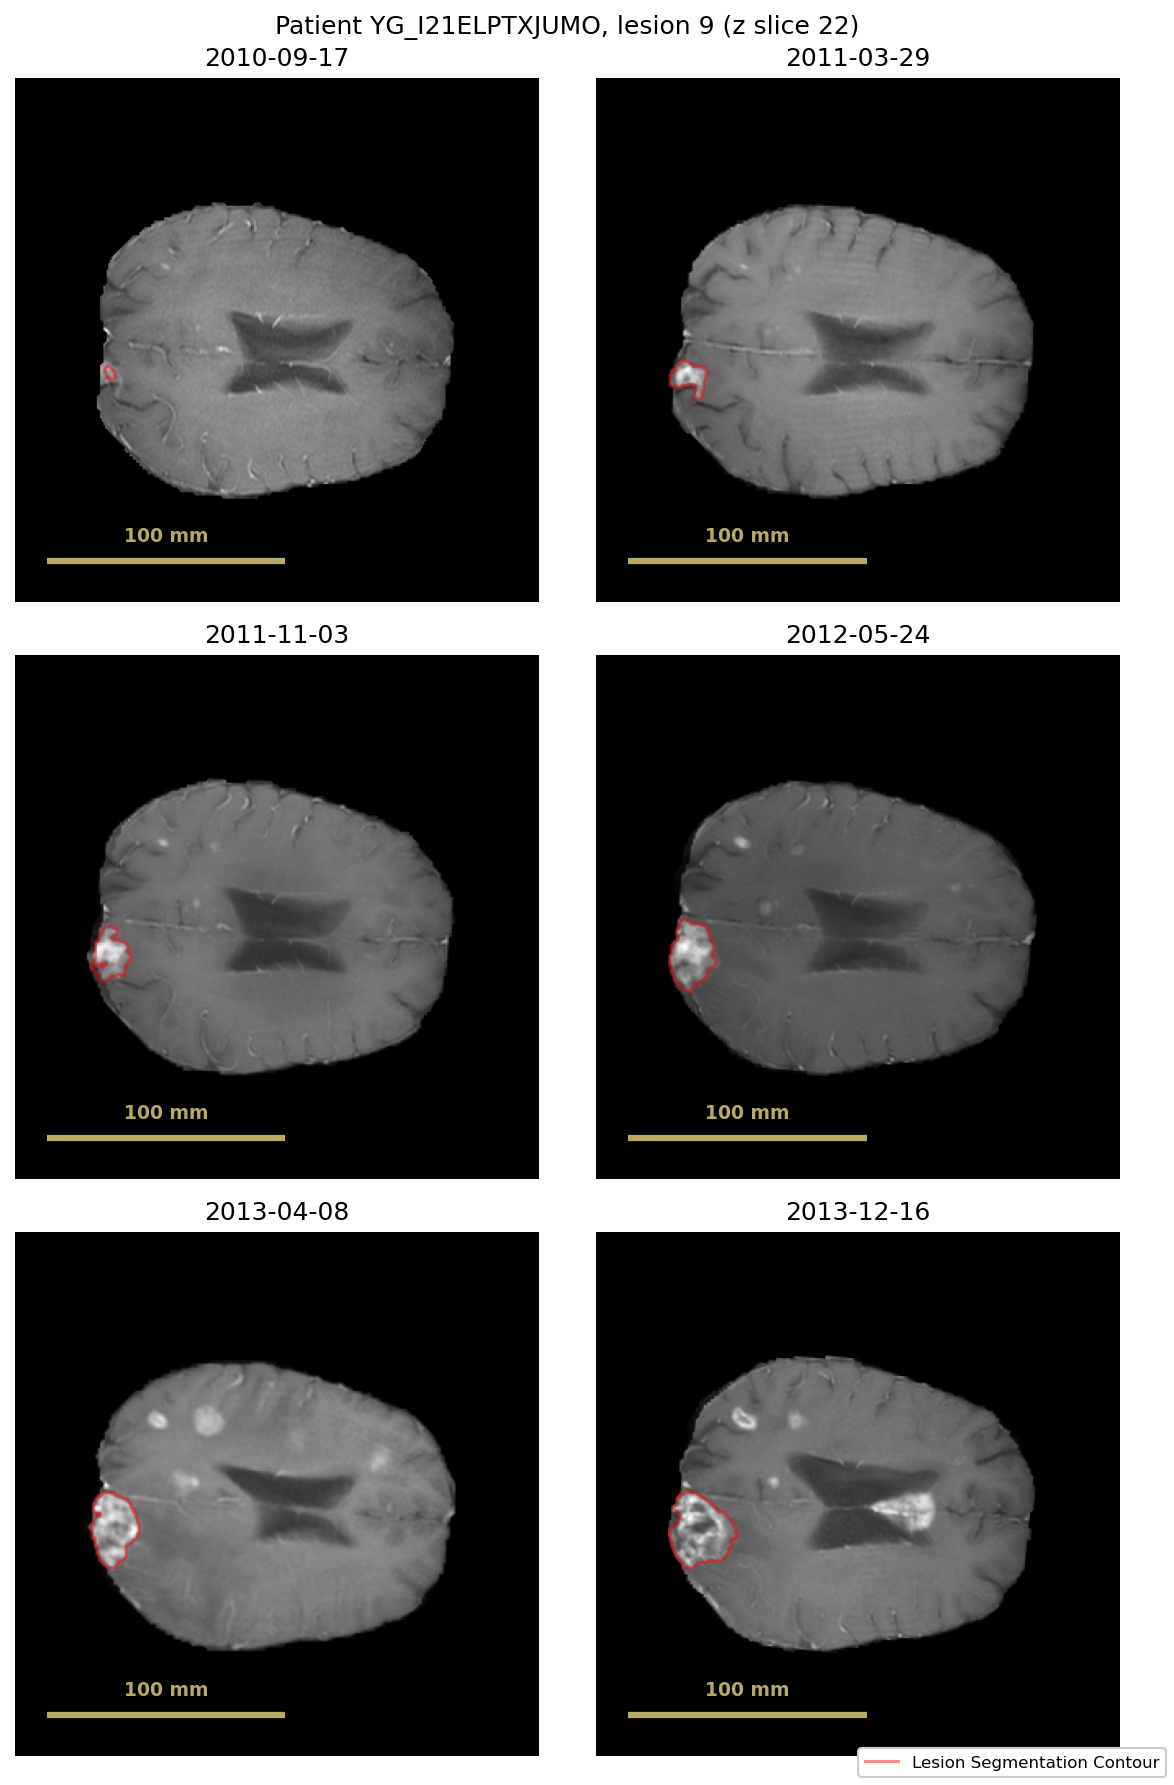

In [5]:
trjs[0].plot_lesion_mri_trajectory(mode='contact_sheet', n_cols=2, skip_every_n=3)


In [6]:
trjs[0].plot_lesion_mri_trajectory(mode='contact_sheet', n_cols=2, skip_every_n=3, zoomed=False)


ValueError: MRI and trajectory shapes differ for 2010-10-29: (256, 320, 35) != (320, 320, 35). Use matching registered volumes.

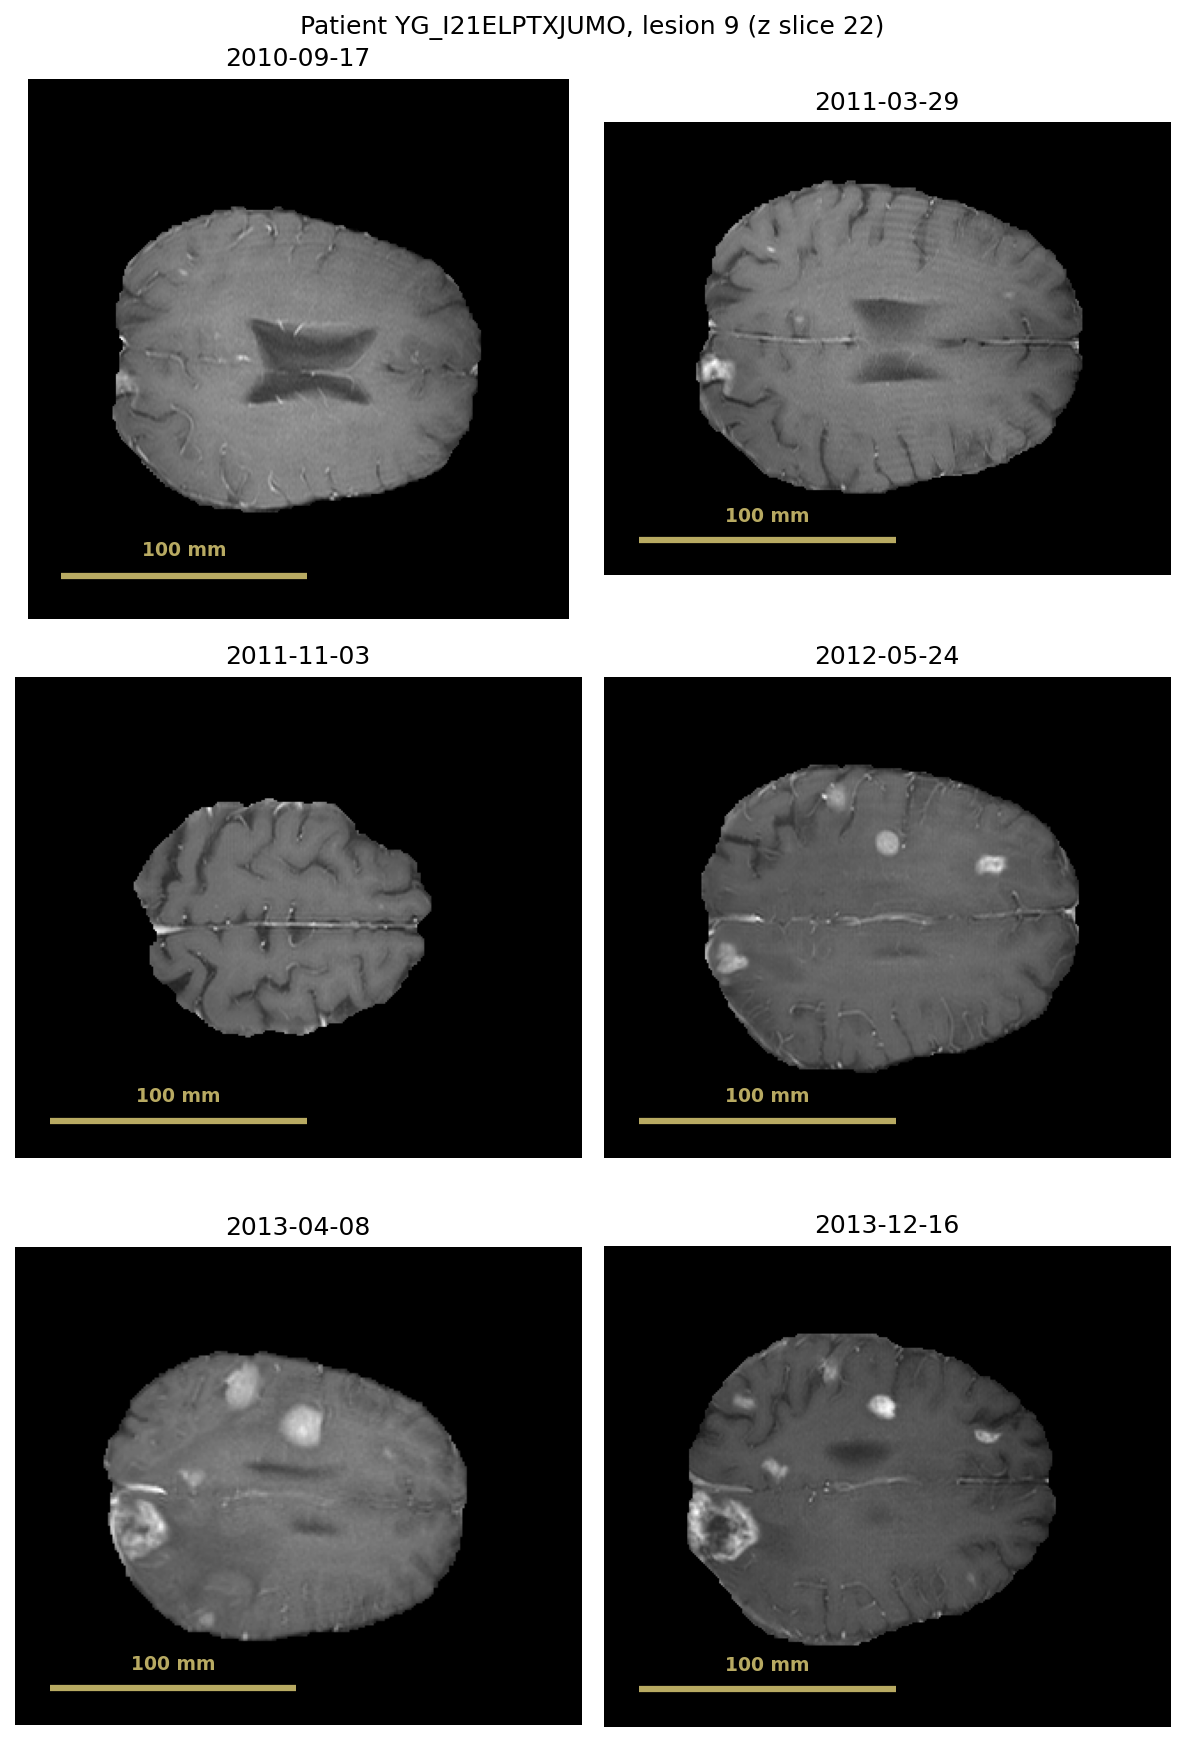

In [16]:
from utils.lesion_trajectory import *

def plot_raw_lesion_mri_trajectory(
        self, mode="animation", n_cols=4, alpha=0.45, jupyter_mode=True, skip_every_n=None):
    """Plot the lesion trajectory over the corresponding MRI scans.

    Args:
        mode: ``"animation"`` for an animated GIF/HTML result or
            ``"contact_sheet"`` for a print-friendly grid of panels.
        output_path: Optional path for saving the animated GIF. It is
            ignored in ``"contact_sheet"`` mode.
        n_cols: Number of columns in the contact sheet.
        fps: Frames per second when saving an animation.
        zoomed: Use the registered, cropped MRI volumes when true.
        alpha: Transparency of the lesion edge.
        jupyter_mode: Return HTML for animations when true; otherwise
            return the Matplotlib animation object.
        plot_segmentation: Whether to plot the lesion segmentation.
        skip_every_n: Skip every nth frame in animation mode.
    Returns:
        An ``IPython.display.HTML`` object or animation in animation
        mode, and the Matplotlib figure in contact-sheet mode.
    """
    if mode not in {"animation", "contact_sheet"}:
        raise ValueError("mode must be 'animation' or 'contact_sheet'")
    if n_cols < 1:
        raise ValueError("n_cols must be at least 1")

    from utils.patient import Patient

    patient = Patient(self.patient_id)
    samples_by_date = {sample.date: sample for sample in patient.samples}
    dates = self.allowed_dates if hasattr(self, "allowed_dates") else self.dates

    frames = []
    lesion_z_positions = []
    for i, date in enumerate(dates):
        sample = samples_by_date.get(date)
        if sample is None:
            raise FileNotFoundError(
                f"No MRI sample found for patient {self.patient_id} on {date}"
            )

        mri, affine = sample.load_mri(zoomed=False, affine=True)

        horizontal_spacing_mm = float(np.linalg.norm(affine[:3, 1]))
        if skip_every_n is not None and i % skip_every_n != 0:
            continue
        frames.append((date, mri, horizontal_spacing_mm))

    if not frames:
        raise ValueError("The lesion trajectory contains no dates")

    if lesion_z_positions:
        z_slice = int(round(float(np.mean(lesion_z_positions))))
    else:
        z_slice = frames[0][1].shape[2] // 2
    z_slice = int(np.clip(z_slice, 0, frames[0][1].shape[2] - 1))

    def choose_scale_bar_length(pixel_extent_mm):
        target = pixel_extent_mm / 4
        magnitude = 10 ** np.floor(np.log10(target))
        for multiplier in (1, 2, 2.5, 5, 10):
            length = multiplier * magnitude
            if length >= target:
                return length
        return 10 * magnitude

    image_width = frames[0][1].shape[1]
    scale_length_mm = choose_scale_bar_length(
        image_width * frames[0][2]
    )
    scale_color = "#b8aa62"

    def draw_frame(ax, frame):
        date, mri, horizontal_spacing_mm = frame
        mri_slice = mri[:, :, 22]
        ax.imshow(
            mri_slice, cmap="gray", vmin=float(np.min(mri_slice)),
            vmax=float(np.max(mri_slice)),
        )
        bar_length_px = scale_length_mm / horizontal_spacing_mm
        bar_x = mri_slice.shape[1] * 0.06
        bar_y = mri_slice.shape[0] * 0.92
        ax.plot(
            [bar_x, bar_x + bar_length_px], [bar_y, bar_y],
            color=scale_color, linewidth=3, solid_capstyle="butt",
        )
        ax.text(
            bar_x + bar_length_px / 2, bar_y - mri_slice.shape[0] * 0.03,
            f"{scale_length_mm:g} mm", color=scale_color, ha="center",
            va="bottom", fontsize=9, weight="bold",
        )

        ax.set_title(date)
        ax.axis("off")

    n_rows = int(np.ceil(len(frames) / n_cols))
    fig, axes = plt.subplots(
        n_rows, n_cols, squeeze=False,
        figsize=(4 * n_cols, 4 * n_rows),
    )
    for ax, frame in zip(axes.flat, frames):
        draw_frame(ax, frame)
    for ax in axes.flat[len(frames):]:
        ax.axis("off")

    fig.suptitle(
        f"Patient {self.patient_id}, lesion {self.label_id} "
        f"(z slice {22})"
    )
    fig.tight_layout()
    if jupyter_mode:
        buffer = io.BytesIO()
        fig.savefig(buffer, format="png", dpi=150, bbox_inches="tight")
        display(Image(data=buffer.getvalue(), format="png"))
        buffer.close()
        plt.close(fig)
        return None
    return fig

trjs[0].plot_raw_lesion_mri_trajectory = plot_raw_lesion_mri_trajectory
trjs[0].plot_raw_lesion_mri_trajectory(trjs[0], mode='contact_sheet', n_cols=2, skip_every_n=3)

In [19]:
trjs[0].patient_id

'YG_I21ELPTXJUMO'